In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
pd.options.display.max_columns = 99

In [ ]:
df = pd.read_csv("/content/customer_segmentation.csv")

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
X = df.iloc[:,8:29]

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X)
X_pca = pca.transform(X)

In [ ]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.9580346892868689)

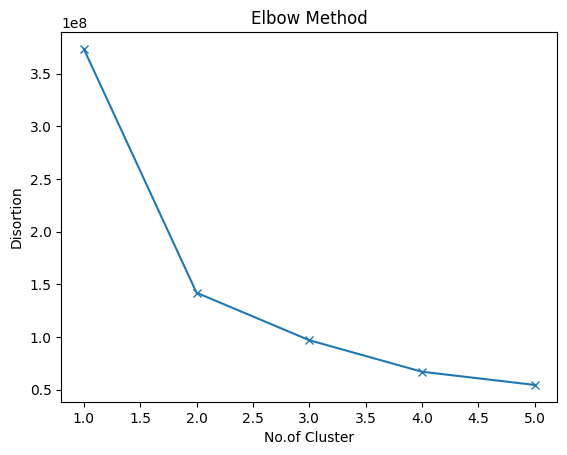

In [ ]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters = i,init = 'k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='x')
plt.xlabel("No.of Cluster")
plt.ylabel("Disortion")
plt.title("Elbow Method")
plt.show()

In [ ]:
model = KMeans(n_clusters=2,init='k-means++',random_state=42,n_init=10)
y = model.fit_predict(X_pca)

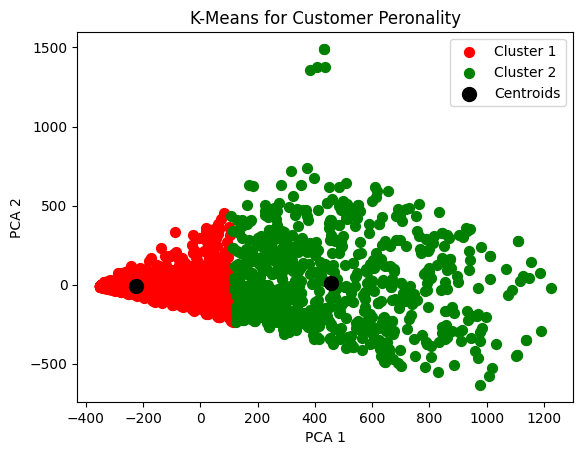

In [ ]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label = "Cluster 1")
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='green',label = "Cluster 2")
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label="Centroids")
plt.title("K-Means for Customer Peronality")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [ ]:
X_question = df.iloc[:,8:29]
q_mean = X_question.mean(axis = 0)
total_mean =q_mean.mean()

In [ ]:
q_mean

,0
Recency,49.109375
MntWines,303.935714
MntFruits,26.302232
MntMeatProducts,166.950000
MntFishProducts,37.525446
MntSweetProducts,27.062946
MntGoldProds,44.021875
NumDealsPurchases,2.325000
NumWebPurchases,4.084821
NumCatalogPurchases,2.662054


In [ ]:
total_mean

np.float64(32.83535289115646)

In [ ]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level = 0,inplace = True)
q_mean.head()

,index,mean
0,Recency,49.109375
1,MntWines,303.935714
2,MntFruits,26.302232
3,MntMeatProducts,166.950000
4,MntFishProducts,37.525446


In [ ]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='index', ylabel='mean'>

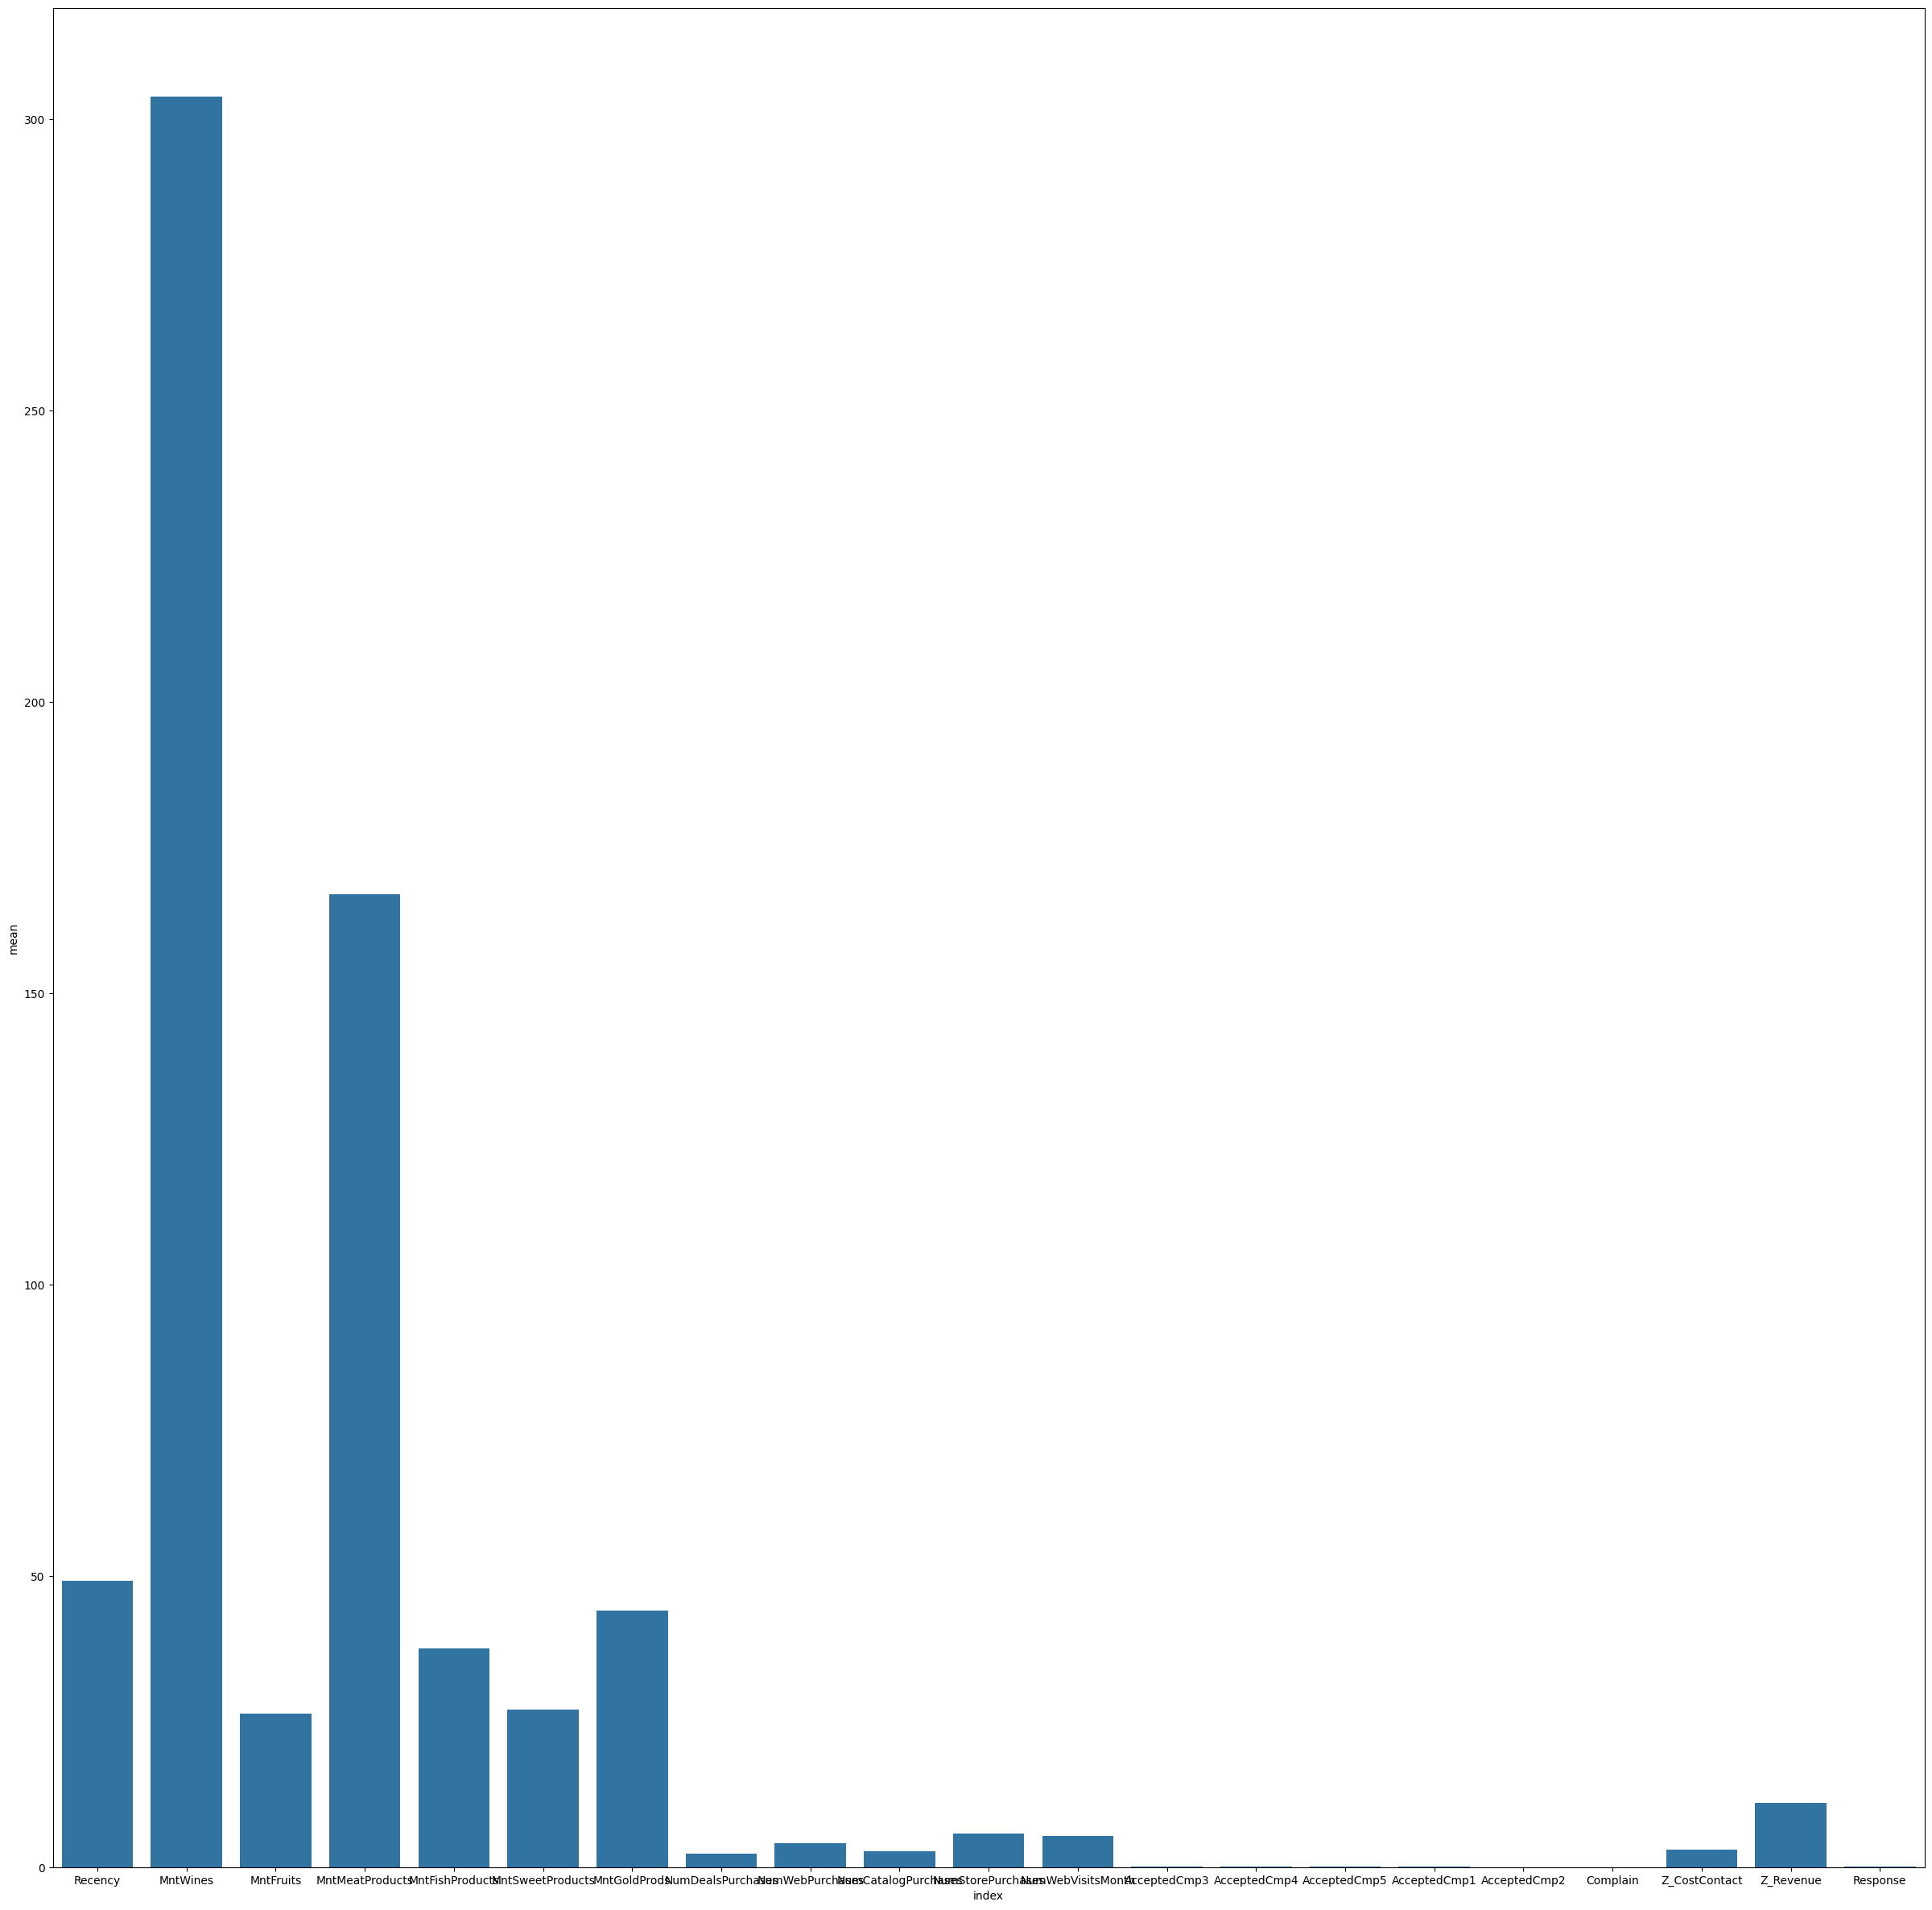

In [ ]:
plt.figure(figsize=(30,30))
sns.barplot(x = 'index',y = 'mean',data = q_mean)

In [ ]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df['Education'] = LE.fit_transform(df['Education'])
df['Marital_Status'] = LE.fit_transform(df['Marital_Status'])
df['Dt_Customer'] = LE.fit_transform(df['Dt_Customer'])

<Axes: >

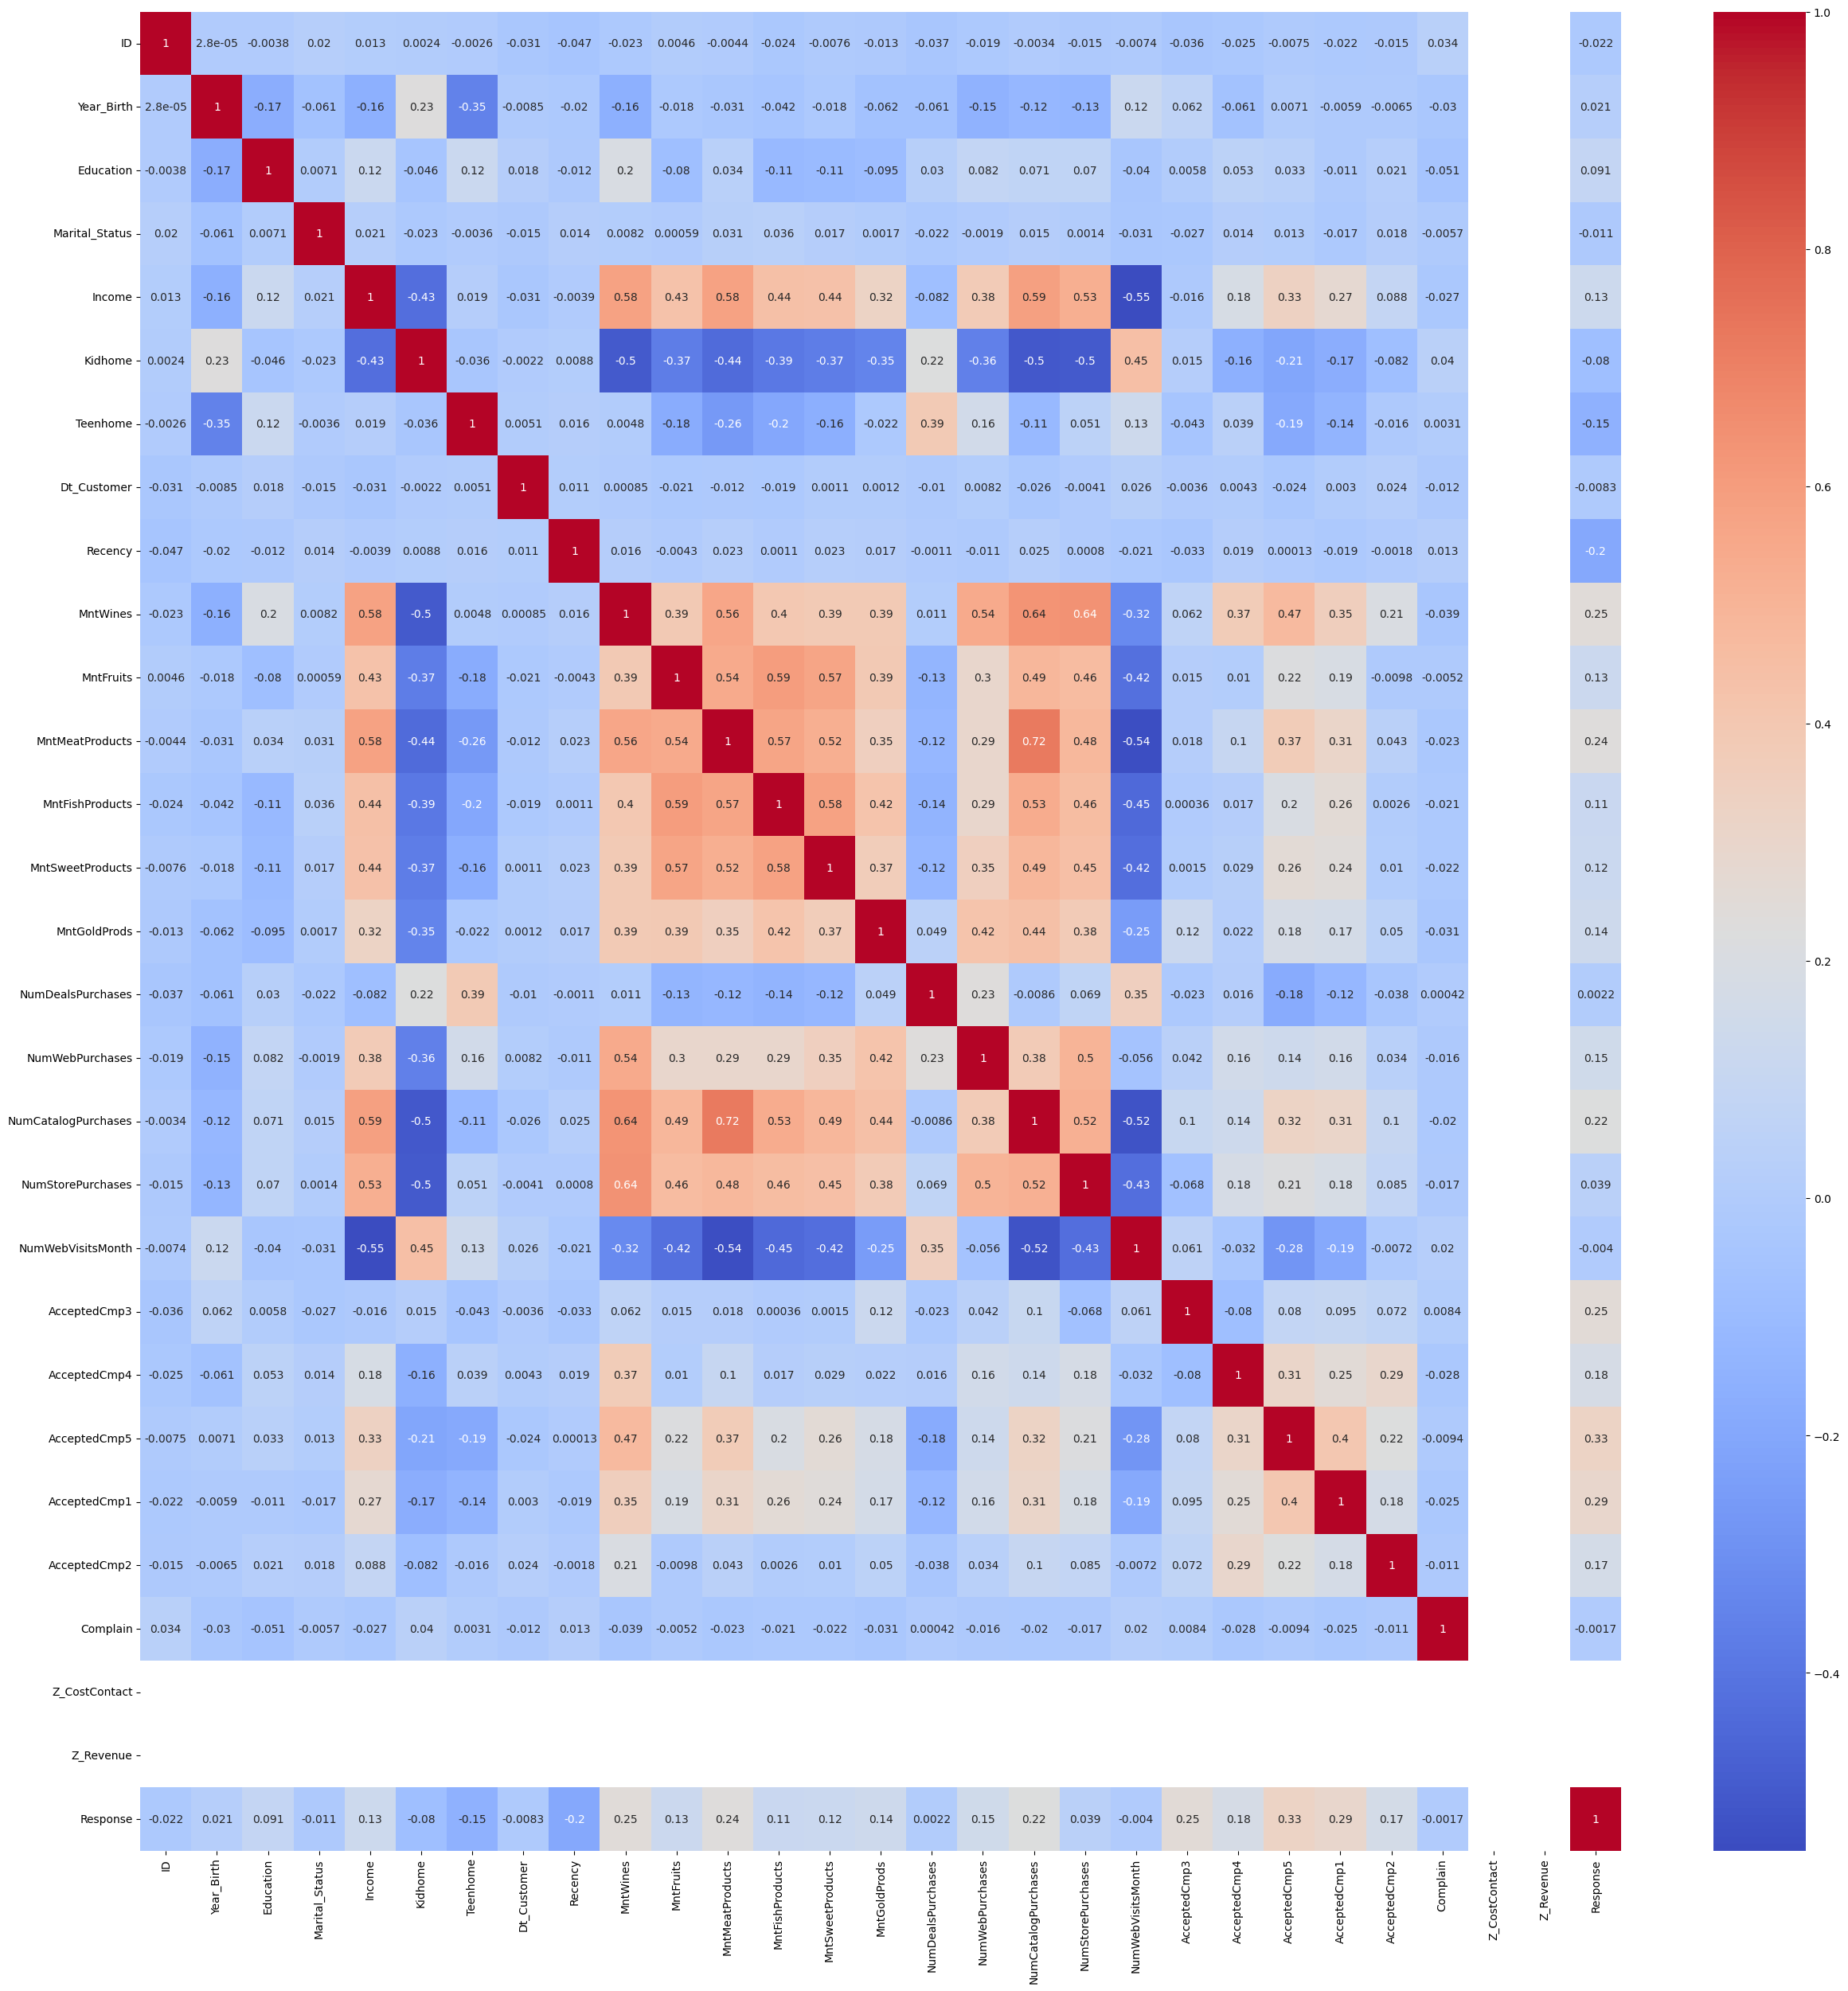

In [ ]:
corr = df.corr()
plt.figure(figsize = (30,30))
sns.heatmap(corr,annot = True,cmap='coolwarm')